In [59]:
#=
November, 2020
Simple simulation of evolving asexual population. Each generation do random mutation
and then Wright-Fisher selection. 

Individual fitnesses, and mutations, are on the log fitness scale. Wright-Fisher selection
is done on the Wrightian (exponentiated) scale. 

All the visualization machinery and stat collection has been stripped out. 
This produces only text files of the population (or a random sample of it) 
at the desired generations. 

Also all the parameter searching machinery has been stripped out.
=#

using DelimitedFiles # For writing the population out
using Distributions  # For SkewNormal, etc
using StatsBase	     # For the weighted sampling
using Plots
using Random

# ---Unchanging simulation parameters---
N = Int(2.7e05) # Population size (static)
reps = 1		# Number of replicate simulations to run
gens = 100		# Stop after this many generations
dj = 100         # maximum time horizon

# Initialize the arrays as arrays of vectors
cv = Vector{Float64}[]  # Creates an empty array of Float64 vectors
mf = Vector{Float64}[]  # Creates an empty array of Float64 vectors
mfs = Matrix{Float64}[]  # Creates an empty array of Float64 vectors
mft = Matrix{Float64}[]  # Creates an empty array of Float64 vectors
df = Vector{Float64}[]  # Creates an empty array of Float64 vectors
dent = Vector{Float64}[]  # Creates an empty array of Float64 vectors

# Now the loop will work

for _ in 1:reps
    push!(cv, zeros(Float64, gens+1))
    push!(mf, zeros(Float64, gens+1))
    push!(mfs, fill(NaN, gens+1, gens+1))
    push!(mft, fill(NaN, gens+1, gens+1))
    push!(df, zeros(Float64, gens+1))
    push!(dent, zeros(Float64, gens+1))
end


# ---------Set up the DFE---------
# Nov 11, 2020
# One DFE for both deleterious and beneficial; it is SkewNormal
# dfe = SkewNormal(0.00787183, 0.120019, -43.7483)

# Define the bivariate normal distribution parameters
m0 = [-0.1, -0.1]   # Mean vector
sdx = 0.1;
sdy = 0.1;
crxy = 0.7;
vx = sdx^2;
vy = sdy^2;
vxy = sdx*sdy*crxy;
cov_matrix = [vx vxy; vxy vy]  # Covariance matrix with correlation of 0.2
dfe = MvNormal(m0, cov_matrix)

m = 1;  # number of generations modifier remains linked recombinants

p0 = [];

# dfe = Normal(-0.02, 0.03)

U = exp(-3.0) # about 0.02

# ---Helper functions go here---
# mutation() = rand(Poisson(U)) # returns 1 if there is a mutation, 0 otherwise
Random.seed!(1234)
# ---Simulation begins here---
# Outer loop: replicate simulation runs
for i = 1:reps 

    println("Starting rep ", i)
    # p = zeros(Float64, N, 2) # The population. Each value is a log fitness
    # hence everyone starting with zero is equivalent to everyone starting with fitness 1
    # u0 = 7.0
    # m1 = [ sum(rand(dfe,rand(Poisson(u0)))) for i in 1:N, j in 1:2 ]
    # p += m1

    p = transpose(rand(dfe,N))
    push!(p0,p)

    # Inner loop: generations
    for j = 1:gens # Start with zero so that at gen N, N generations have occured (?)
        
        if j % 25 == 0
            println("generation "*string(j))
        end 

        px = copy(p[:,1])
        py = copy(p[:,2])
        px1 = copy(px)
        py1 = copy(py)
        fx = (t) -> sum(px1 .* exp.(px1*t))/sum(exp.(px1*t))
        fy = (t) -> sum(py1 .* exp.(py1*t))/sum(exp.(py1*t))
        for k in j:min(j+dj,gens)
            dt = k - j
                mfs[i][j, k] = mean(px) + mean(py)
                if dt == m
                    px2 = copy(px)
                    py2 = copy(py)
                    fxy = (t) -> sum((px2 + py2) .* exp.((px2 + py2)*t))/sum(exp.((px2 + py2)*t))
                end
                if dt <= m 
                    mft[i][j, k] = fx(dt) + fy(dt)
                else
                    mft[i][j, k] = fxy(dt - m)
                end
                
                if dt <= m
                    wx = weights(exp.(px))
                    wy = weights(exp.(py))
                    ngx = sample(1:N, wx, N)
                    ngy = sample(1:N, wy, N)
                else
                    wxy = weights(exp.(px + py))
                    ngxy = sample(1:N, wxy, N)
                    ngx = ngxy
                    ngy = ngxy
                end

                px = px[ngx] # the new post-selection population
                py = py[ngy] # the new post-selection population
                
        end

        cv[i][j] = cov(p[:,1], p[:,2])
        mf[i][j] = mean(p[:,1] + p[:,2])

        ww = weights(exp.(p[:,1] + p[:,2])) # weights() takes care of standardizing fitnesses
        next_gen = sample(1:N, ww, N)  # Note that we select on Wrightian fitness not log fitness

        p = p[next_gen, :] # the new post-selection population

    end # end of generation loop

end # end of replicate loop

println("All done")

plot([ x for x = 1:gens], cv)

plot([ x for x = 1:gens], mf)



Starting rep 1
generation 25
generation 50
generation 75
generation 100
All done


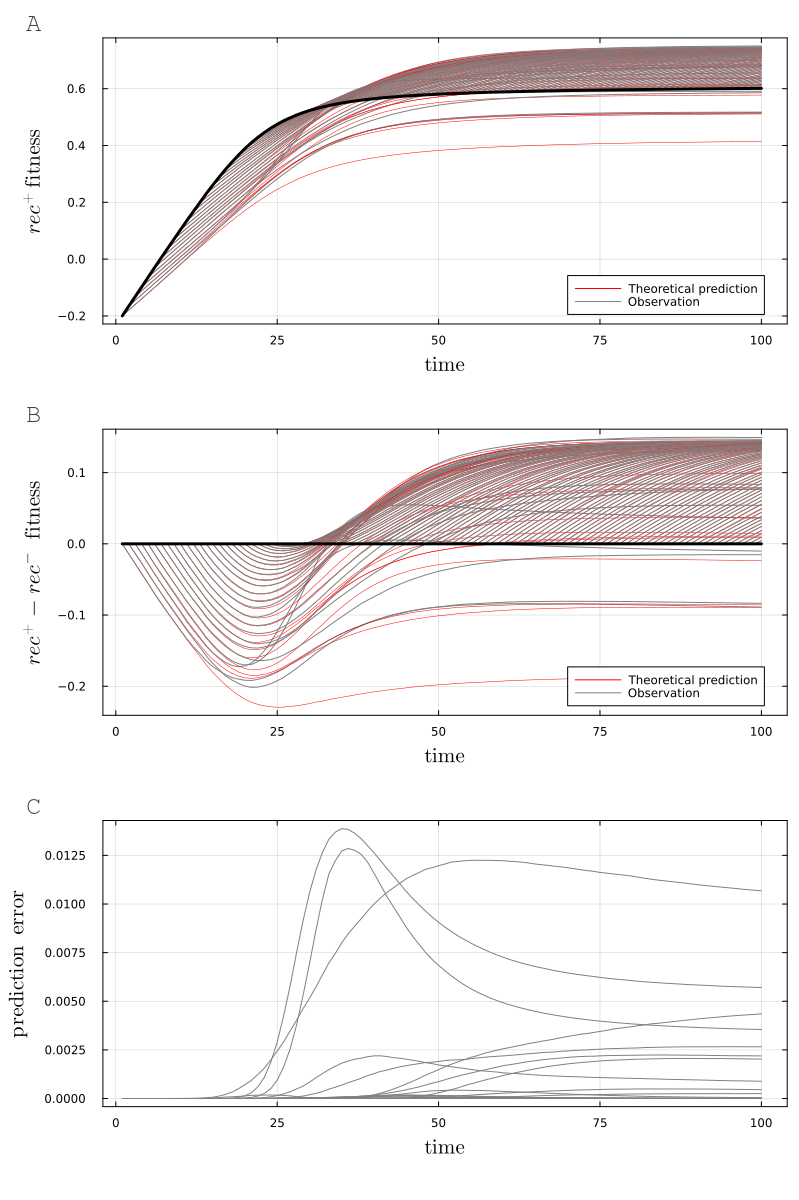

In [114]:
using Plots
using Plots.PlotMeasures # Import PlotMeasures for units like `px`
gr()
using LaTeXStrings

pl1 = plot(leftmargin=30px, bottommargin=30px, topmargin=30px, size=(800, 400)) 
plot!(pl1, xlabel=L"\mathrm{time}", ylabel=L"rec^{+} \, \mathrm{fitness}", guidefontsize=14, framestyle=:box)
for i in 1:gens
    plot!(pl1, mft[1][i, :], label=false, color=:red, lw=0.5)
    plot!(pl1, mfs[1][i, :], label=false, color=:gray)
end
plot!(pl1, mf[1][1:end-1], label=false, color=:black, lw=3)
plot!(1:100, fill(NaN, 100), color=:red, label="Theoretical prediction")
plot!(1:100, fill(NaN, 100), color=:gray, label="Observation")
annotate!(pl1, (-0.1, 1.05), text("A", :black, :bold, 20))

pl2 = plot(leftmargin=30px, bottommargin=30px, size=(800, 400)) 
plot!(pl2, xlabel=L"\mathrm{time}", ylabel=L"rec^{+} - rec^{-} ~~ \mathrm{fitness}", guidefontsize=14, framestyle=:box)
for i in 1:gens
    plot!(pl2, mft[1][i, :] - mf[1], label=false, color=:red, lw=0.5)
    plot!(pl2, mfs[1][i, :] - mf[1], label=false, color=:gray)
end
plot!(pl2, zeros(length(mf[1][1:end-1])), label=false, color=:black, lw=3)
plot!(1:100, fill(NaN, 100), color=:red, label="Theoretical prediction")
plot!(1:100, fill(NaN, 100), color=:gray, label="Observation")
annotate!(pl2, (-0.1, 1.05), text("B", :black, :bold, 20))

pl3 = plot(leftmargin=30px, bottommargin=30px, size=(800, 400)) 
plot!(pl3, xlabel=L"\mathrm{time}", ylabel=L"\mathrm{prediction ~~ error}", guidefontsize=14, framestyle=:box)
for i in 1:gens
    plot!(pl3, (mft[1][i, :] - mfs[1][i, :]).^2, label=false, color=:gray)
    # plot!(plt, mfs[1][i, :], label=false, color=:gray)
end
annotate!(pl3, (-0.1, 1.05), text("C", :black, :bold, 20))
# Stack them vertically
plot(pl1, pl2, pl3, layout = @layout([a; b; c]), size=(800, 1200))

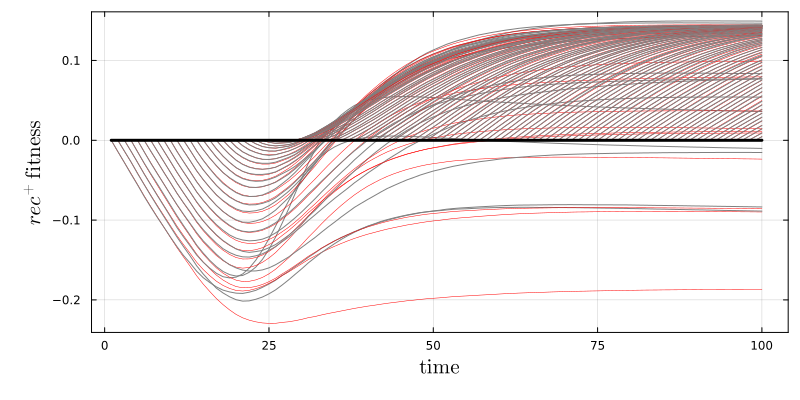

In [89]:
plt = plot(leftmargin=30px, bottommargin=30px, size=(800, 400)) 
plot!(plt, xlabel=L"\mathrm{time}", ylabel=L"rec^{+} \, \mathrm{fitness}", guidefontsize=14, framestyle=:box)
for i in 1:gens
    plot!(plt, mft[1][i, :] - mf[1], label=false, color=:red, lw=0.5)
    plot!(plt, mfs[1][i, :] - mf[1], label=false, color=:gray)
end
plot!(plt, zeros(length(mf[1][1:end-1])), label=false, color=:black, lw=3)
display(plt)

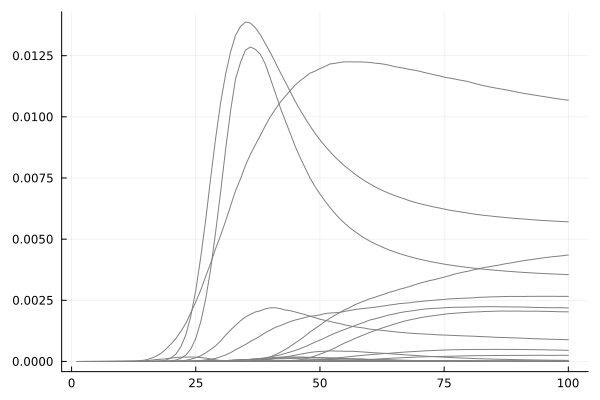

In [96]:
plt = plot()
for i in 1:gens
    plot!(plt, (mft[1][i, :] - mfs[1][i, :]).^2, label=false, color=:gray)
    # plot!(plt, mfs[1][i, :], label=false, color=:gray)
end

display(plt)

In [62]:
using Pkg
Pkg.add("KernelDensity")

   Resolving package versions...
   Installed KernelDensity ─ v0.6.10
    Updating `~/.julia/environments/v1.10/Project.toml`
  [5ab0869b] + KernelDensity v0.6.10
    Updating `~/.julia/environments/v1.10/Manifest.toml`
  [5ab0869b] ↑ KernelDensity v0.6.9 ⇒ v0.6.10
Precompiling project...
  ✓ KernelDensity
  ✓ MCMCChains
  ✓ StatsPlots
  ✓ AdvancedHMC → AdvancedHMCMCMCChainsExt
  ✓ AdvancedMH → AdvancedMHMCMCChainsExt
  ✓ DynamicPPL → DynamicPPLMCMCChainsExt
  ✓ Makie
  ✓ DomainSets → DomainSetsMakieExt
  ✓ SciMLBase → SciMLBaseMakieExt
  ✓ Turing
  ✓ Turing → TuringOptimExt
  ✓ CairoMakie
  ✓ GLMakie
  13 dependencies successfully precompiled in 120 seconds. 796 already precompiled. 2 skipped during auto due to previous errors.


In [ ]:
using KernelDensity, Plots

trajectories = mfs[1]

tsteps = size(trajectories, 2)
ys = range(minimum(skipmissing(trajectories)), stop=maximum(skipmissing(trajectories)), length=200)
density = zeros(length(ys), tsteps)

for j in 1:tsteps
    kd = kde(trajectories[:, j], ys)
    density[:, j] = kd.density
end

density ./= maximum(density)

heatmap(1:tsteps, ys, density;
    xlabel="Time", ylabel="Value", c=:grays, colorbar=false,
    title="KDE-smoothed Trajectory Density")


MethodError: MethodError: no method matching size(::Base.SkipMissing{Matrix{Float64}}, ::Int64)

Closest candidates are:
  size(!Matched::BitVector, ::Integer)
   @ Base bitarray.jl:107
  size(!Matched::Type{<:LinearAlgebra.Diagonal{T, StaticArraysCore.SVector{N, T}} where T}, ::Int64) where N
   @ StaticArrays ~/.julia/packages/StaticArrays/LSPcF/src/SDiagonal.jl:18
  size(!Matched::Type{<:Union{LinearAlgebra.Adjoint{T, <:Union{StaticArraysCore.StaticArray{Tuple{var"#s2"}, T, 1} where var"#s2", StaticArraysCore.StaticArray{Tuple{var"#s3", var"#s4"}, T, 2} where {var"#s3", var"#s4"}}}, LinearAlgebra.Diagonal{T, <:StaticArraysCore.StaticArray{Tuple{var"#s14"}, T, 1} where var"#s14"}, LinearAlgebra.Hermitian{T, <:StaticArraysCore.StaticArray{Tuple{var"#s11", var"#s12"}, T, 2} where {var"#s11", var"#s12"}}, LinearAlgebra.LowerTriangular{T, <:StaticArraysCore.StaticArray{Tuple{var"#s19", var"#s20"}, T, 2} where {var"#s19", var"#s20"}}, LinearAlgebra.Symmetric{T, <:StaticArraysCore.StaticAr

In [76]:
sk = skipmissing(trajectories)

skipmissing([-0.19982218911685767 -0.1795672989648171 … 0.5175108320512133 NaN; NaN -0.1655433417880769 … 0.5123112349462663 NaN; … ; NaN NaN … 0.6010724487841059 NaN; NaN NaN … NaN NaN])

In [83]:
sk1 = sk[10,:]

101-element Vector{Float64}:
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
   0.10273159680352907
   ⋮
   0.7302034385779235
   0.730530388557014
   0.7308022695033665
   0.7310959293717536
   0.7313501405785829
   0.7315989643254546
   0.7318526088807571
   0.7320797138600934
 NaN

In [84]:
sk1[.!isnan.(sk1)]

91-element Vector{Float64}:
 0.10273159680352907
 0.12151978426302384
 0.14055941537050193
 0.1591855071745602
 0.17821231695609482
 0.19714014059241508
 0.21582526146208525
 0.23432984800148654
 0.2526238506775804
 0.271149785740197
 ⋮
 0.7298968385865838
 0.7302034385779235
 0.730530388557014
 0.7308022695033665
 0.7310959293717536
 0.7313501405785829
 0.7315989643254546
 0.7318526088807571
 0.7320797138600934